# Black Friday Sales Prediction

## Project Overview
The objective of this project is to predict the purchase amount of customers during the Black Friday sale based on customer demographics and product information.

## Dataset
Dataset: BlackFridaySales.csv

Target Variable:
- Purchase

Machine Learning Algorithm:
- Random Forest Regressor

Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

## Load Dataset
Read the dataset and display the first few rows.

In [12]:
df = pd.read_csv("/content/BlackFridaySales.csv")

df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


## Dataset Information
Check shape, data types, and missing values.

In [13]:
print("Shape :", df.shape)

df.info()

Shape : (550068, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50

In [14]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


## Statistical Summary

In [15]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


# Exploratory Data Analysis

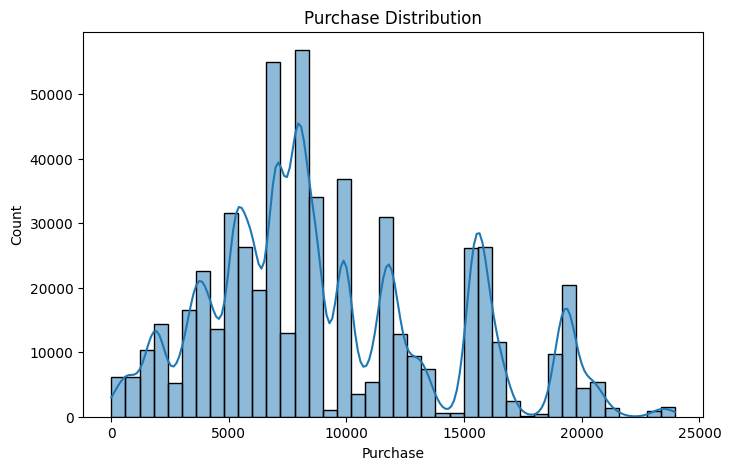

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Purchase"], bins=40, kde=True)
plt.title("Purchase Distribution")
plt.show()

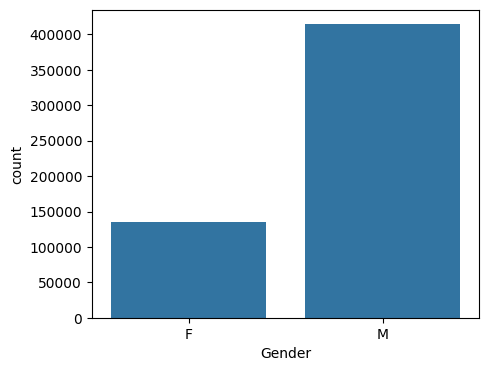

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df)
plt.show()

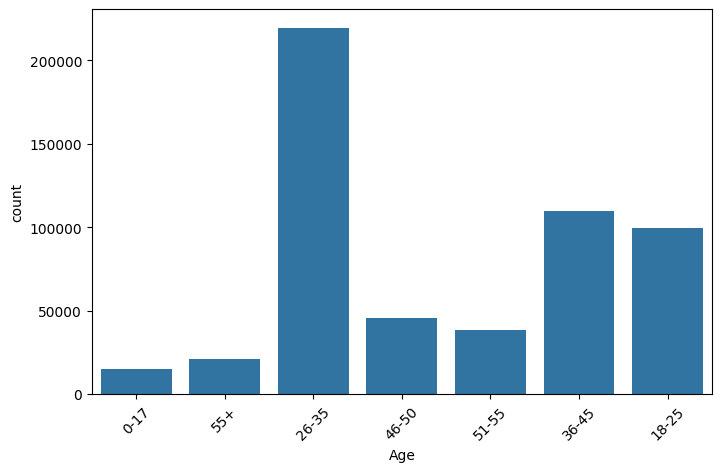

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x="Age", data=df)
plt.xticks(rotation=45)
plt.show()

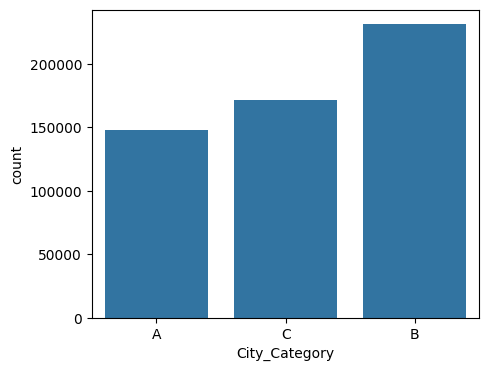

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x="City_Category", data=df)
plt.show()

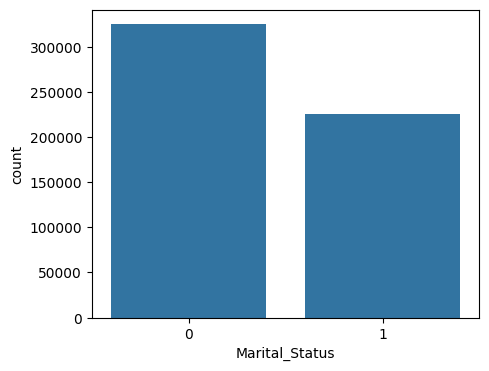

In [20]:
plt.figure(figsize=(5,4))
sns.countplot(x="Marital_Status", data=df)
plt.show()

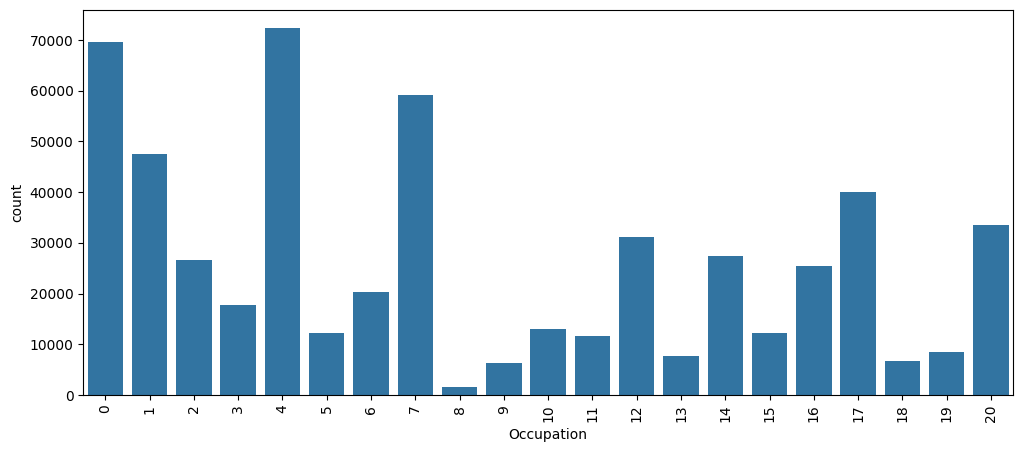

In [21]:
plt.figure(figsize=(12,5))
sns.countplot(x="Occupation", data=df)
plt.xticks(rotation=90)
plt.show()

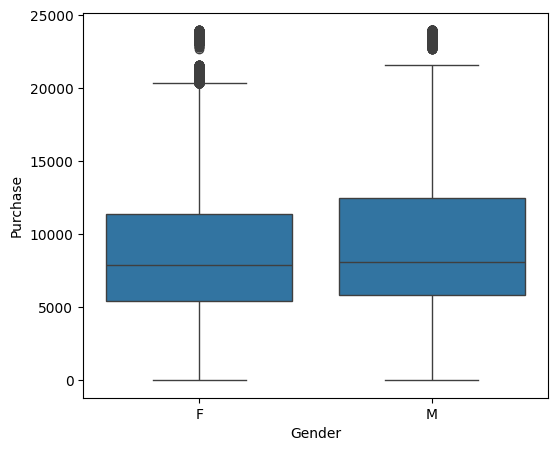

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Gender", y="Purchase", data=df)
plt.show()

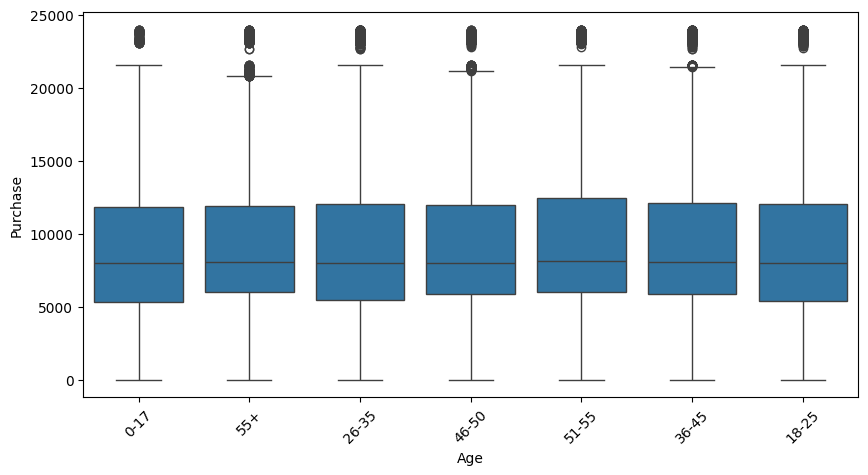

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Age", y="Purchase", data=df)
plt.xticks(rotation=45)
plt.show()

## Handle Missing Values
Replace missing values in Product_Category_2 and Product_Category_3.

In [24]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(0)
df["Product_Category_3"] = df["Product_Category_3"].fillna(0)

## Remove Columns

In [25]:
df = df.drop(["User_ID","Product_ID"], axis=1)

## Encode Categorical Variables

In [27]:
encoder = LabelEncoder()

cols = [
    "Gender",
    "Age",
    "City_Category",
    "Stay_In_Current_City_Years"
]

for col in cols:
    df[col] = encoder.fit_transform(df[col])

## Correlation Matrix

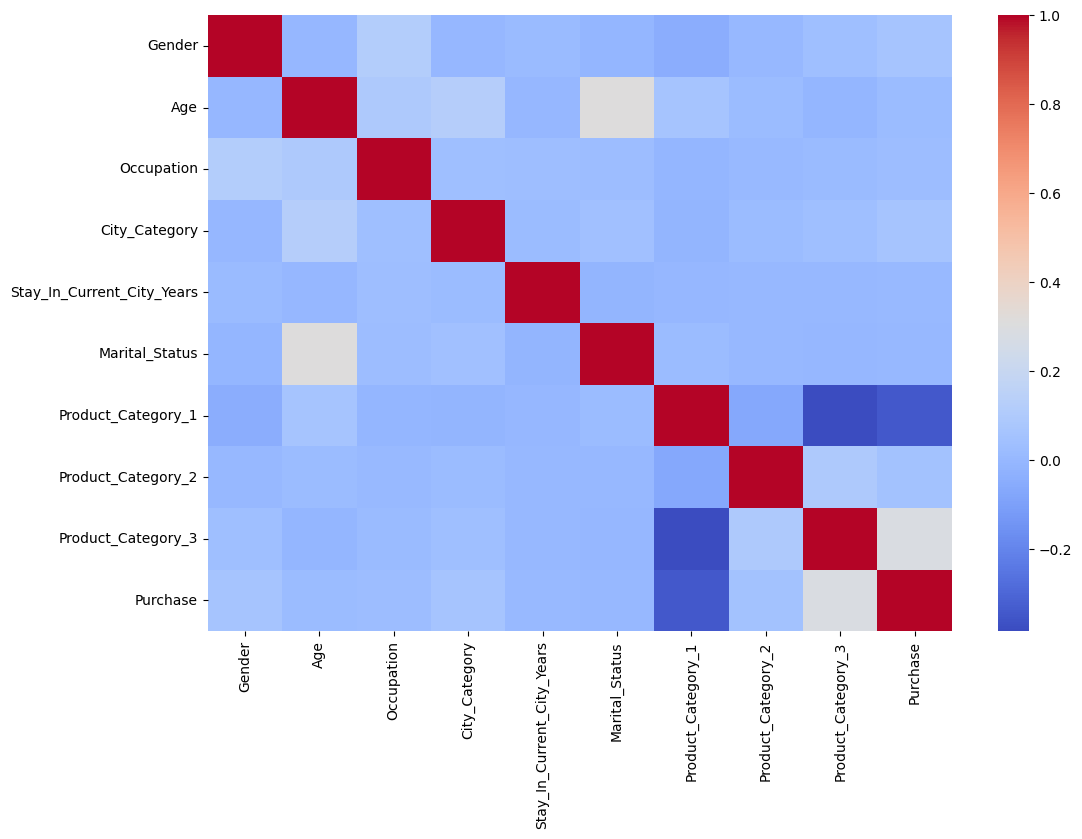

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.show()

## Split Features and Target

In [29]:
X = df.drop("Purchase", axis=1)

y = df["Purchase"]

## Train Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Random Forest Regressor

In [31]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

## Model Prediction

In [34]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2225.54831005045
MSE: 9359895.609596014
RMSE: 3059.394647572623
R² Score: 0.6274843358555339


## Actual vs Predicted Values

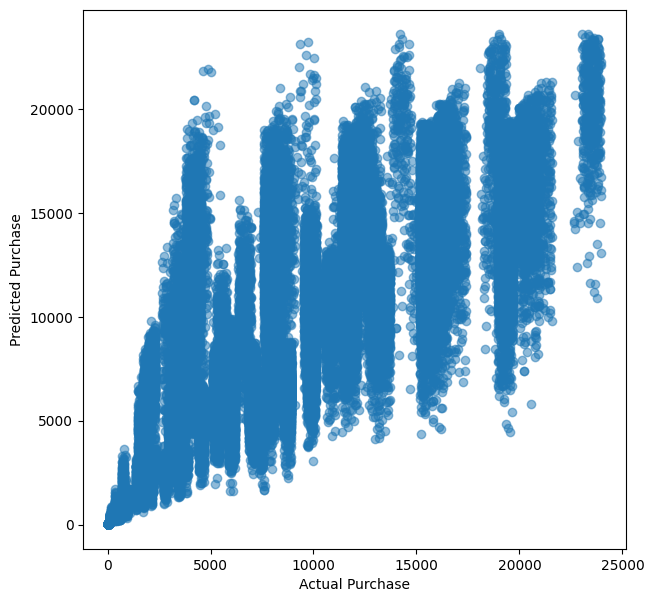

In [35]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Purchase")
plt.ylabel("Predicted Purchase")

plt.show()

## Feature Importance

In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Product_Category_1,0.767397
2,Occupation,0.062704
4,Stay_In_Current_City_Years,0.043400
1,Age,0.038189
7,Product_Category_2,0.026397
8,Product_Category_3,0.017344
5,Marital_Status,0.016521
3,City_Category,0.014953
0,Gender,0.013094


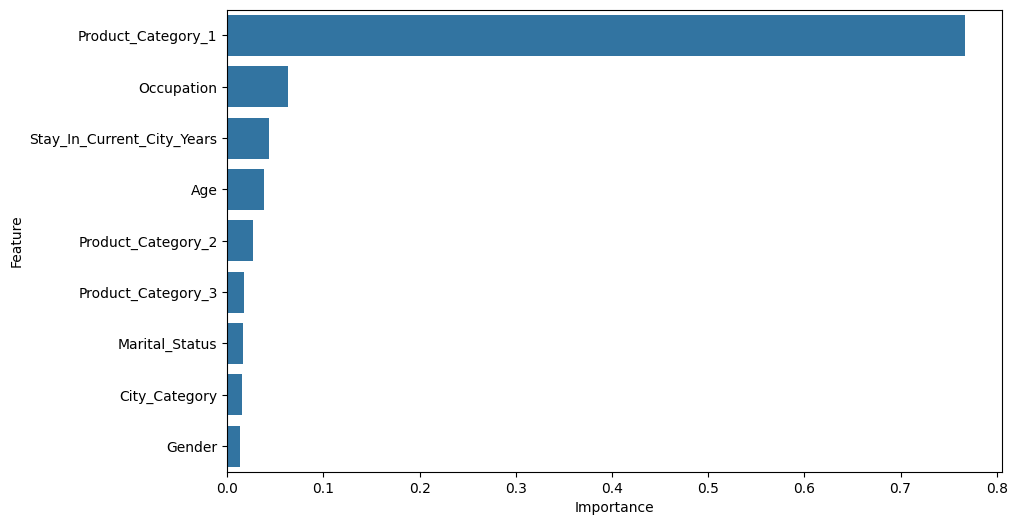

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

## Predict on a Sample Customer

In [38]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Purchase Amount:", prediction[0])

Predicted Purchase Amount: 9963.803333333333


## Save Trained Model

In [39]:
import joblib

joblib.dump(model, "black_friday_sales_model.pkl")

['black_friday_sales_model.pkl']

## Load Saved Model

In [40]:
loaded_model = joblib.load("black_friday_sales_model.pkl")

# Conclusion

In this project, we:

- Loaded and explored the Black Friday Sales dataset.
- Performed data preprocessing by handling missing values and encoding categorical features.
- Conducted exploratory data analysis (EDA) to understand customer demographics and purchase behavior.
- Trained a Random Forest Regressor to predict customer purchase amounts.
- Evaluated the model using MAE, RMSE, and R² Score.
- Analyzed feature importance to identify the variables that most influence purchase predictions.
- Saved the trained model for future use.

This workflow demonstrates a complete machine learning regression pipeline, from data preprocessing to model deployment readiness.